<a href="https://colab.research.google.com/github/shantaislamroza/FlyrankML/blob/main/work/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import duckdb
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_secret (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

files = con.execute("""
    SELECT file
    FROM glob('hf://datasets/FlyRank/internship-warehouse/**/*.parquet')
""").df()

display(files)

,file
0,hf://datasets/FlyRank/internship-warehouse/dim...
1,hf://datasets/FlyRank/internship-warehouse/dim...
2,hf://datasets/FlyRank/internship-warehouse/fac...
3,hf://datasets/FlyRank/internship-warehouse/fac...
4,hf://datasets/FlyRank/internship-warehouse/fac...
5,hf://datasets/FlyRank/internship-warehouse/fac...
6,hf://datasets/FlyRank/internship-warehouse/fac...
7,hf://datasets/FlyRank/internship-warehouse/fac...
8,hf://datasets/FlyRank/internship-warehouse/fac...
9,hf://datasets/FlyRank/internship-warehouse/fac...


In [5]:
for f in files['file'].tolist():
    print(f)

hf://datasets/FlyRank/internship-warehouse/dim_clients.parquet
hf://datasets/FlyRank/internship-warehouse/dim_content.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-01/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-02/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-03/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-04/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-05/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-06/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-07/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2025-08/data_0.parquet
hf://datasets/FlyRank/internship-warehouse/fact_co

In [6]:
query = """
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        ga4_sessions,
        ga4_total_engagement_sec
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/*/*.parquet'
    WHERE gsc_impressions >= 10
    LIMIT 25000
"""

print("Loading performance data...")
df = con.execute(query).df()

print("Data loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Loading performance data...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded successfully.
Shape: (25000, 8)


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,ga4_sessions,ga4_total_engagement_sec
0,2025-01-27,client_9958f0a7ae1df715,content_3b70a18ea133b2bb,30,0,3.833333,0,0
1,2025-01-27,client_9958f0a7ae1df715,content_c782fa8abd4fce5e,21,0,50.000000,0,0
2,2025-01-27,client_9958f0a7ae1df715,content_ae5e5fd6edff550f,13,0,9.769231,0,0
3,2025-01-27,client_9958f0a7ae1df715,content_a64143f6e4a21ffe,29,0,12.275862,0,0
4,2025-01-27,client_9958f0a7ae1df715,content_da9cd3207814ec8d,32,0,6.656250,0,0


In [7]:
import numpy as np

df['actual_ctr'] = df['gsc_clicks'] / df['gsc_impressions']
df['engagement_rate'] = np.where(
    df['ga4_sessions'] > 0,
    df['ga4_total_engagement_sec'] / df['ga4_sessions'],
    0.0
)

df['log_impressions'] = np.log1p(df['gsc_impressions'])
df = df.dropna(subset=['gsc_avg_position', 'actual_ctr']).copy()

feature_cols = ['gsc_avg_position', 'log_impressions', 'engagement_rate']
X = df[feature_cols]
y = df['actual_ctr']

print("Features ready:")
print(f"Total samples: {len(df)}")
print("\nFeature Summary:")
display(X.describe())

Features ready:
Total samples: 24999

Feature Summary:


,gsc_avg_position,log_impressions,engagement_rate
count,24999.000000,24999.000000,24999.0
mean,27.137361,3.196204,0.0
std,20.372951,0.626816,0.0
min,0.000000,2.397895,0.0
25%,10.000000,2.708050,0.0
50%,20.823529,3.091042,0.0
75%,40.446360,3.555348,0.0
max,95.593220,6.708084,0.0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X[['gsc_avg_position', 'log_impressions']],
    y,
    test_size=0.2,
    random_state=42
)

# Baseline model (predicts historical mean)
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions & evaluation
rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("--- Model Evaluation ---")
print(f"Baseline MSE : {baseline_mse:.6f} | Baseline MAE : {baseline_mae:.6f}")
print(f"Model MSE    : {rf_mse:.6f} | Model MAE    : {rf_mae:.6f}")
print(f"Model R2 Score: {rf_r2:.4f}")

--- Model Evaluation ---
Baseline MSE : 0.000450 | Baseline MAE : 0.011573
Model MSE    : 0.000411 | Model MAE    : 0.010304
Model R2 Score: 0.0850


In [9]:
test_indices = X_test.index
scoring_df = df.loc[test_indices].copy()

scoring_df['expected_ctr'] = rf_pred
scoring_df['ctr_gap'] = scoring_df['expected_ctr'] - scoring_df['actual_ctr']

# Calculate potential lost clicks
scoring_df['lost_clicks_potential'] = np.maximum(
    0, scoring_df['ctr_gap'] * scoring_df['gsc_impressions']
)

# Opportunity Score (weighted by impressions and gap)
scoring_df['opportunity_score'] = (
    scoring_df['lost_clicks_potential'] * (1 / (scoring_df['gsc_avg_position'] + 1))
)

# Filter top ranked opportunities
ranked_recommendations = scoring_df.sort_values(
    by='opportunity_score', ascending=False
)[[
    'content_hash_id',
    'client_hash_id',
    'gsc_impressions',
    'gsc_clicks',
    'gsc_avg_position',
    'actual_ctr',
    'expected_ctr',
    'lost_clicks_potential',
    'opportunity_score'
]].head(10)

print("--- Top 10 Ranked Content Opportunities ---")
display(ranked_recommendations)

--- Top 10 Ranked Content Opportunities ---


,content_hash_id,client_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,actual_ctr,expected_ctr,lost_clicks_potential,opportunity_score
22438,content_ad76627289f740d8,client_9958f0a7ae1df715,226,1,3.075221,0.004425,0.016085,2.635101,0.646616
12779,content_d02be57d816cf3d7,client_9958f0a7ae1df715,311,0,4.749196,0.000000,0.011708,3.641136,0.633330
24420,content_aead070e1f002702,client_9958f0a7ae1df715,265,0,5.505660,0.000000,0.010478,2.776582,0.426795
4187,content_79bfcf05bc81bf82,client_9958f0a7ae1df715,274,3,1.492701,0.010949,0.014257,0.906384,0.363615
943,content_d02be57d816cf3d7,client_9958f0a7ae1df715,118,0,2.661017,0.000000,0.011153,1.316009,0.359465
1574,content_d02be57d816cf3d7,client_9958f0a7ae1df715,142,0,2.845070,0.000000,0.009437,1.340084,0.348520
35,content_84f5a9ecfefa108e,client_9958f0a7ae1df715,65,0,1.476923,0.000000,0.011654,0.757518,0.305830
13358,content_79bfcf05bc81bf82,client_9958f0a7ae1df715,230,3,1.686957,0.013043,0.016518,0.799187,0.297432
3255,content_e032cc1f6c7fef57,client_73cda7b4e4f265ea,158,0,6.670886,0.000000,0.013616,2.151405,0.280464
10773,content_c12f046f428e481f,client_9958f0a7ae1df715,40,0,0.200000,0.000000,0.008321,0.332834,0.277361


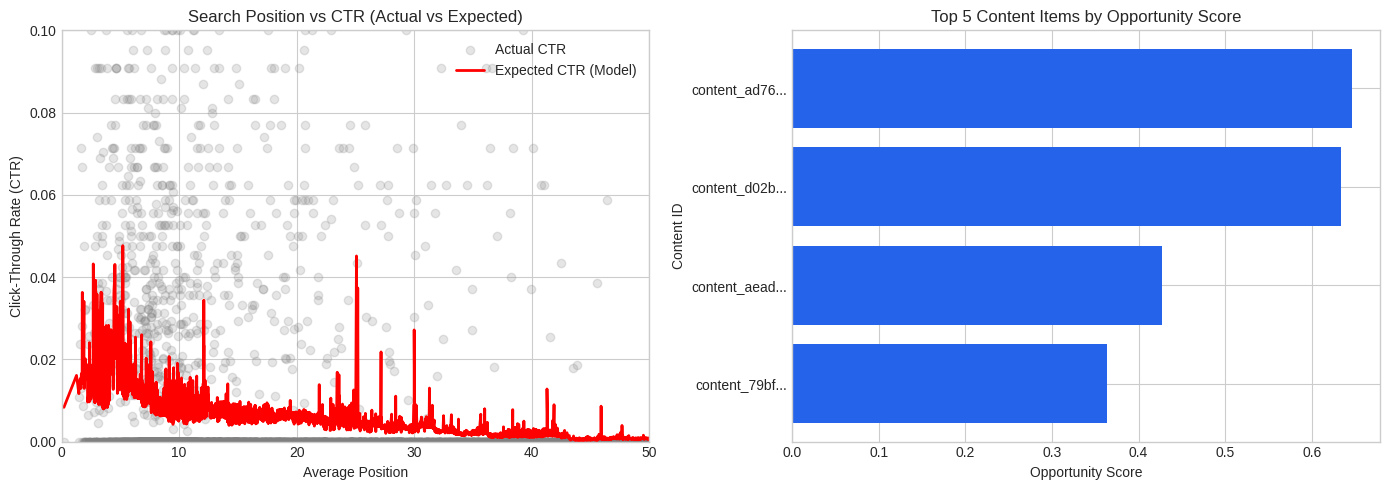

Plot saved as capstone_results_plot.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Position vs Actual CTR with Model Trend
axes[0].scatter(X_test['gsc_avg_position'], y_test, alpha=0.2, color='gray', label='Actual CTR')
sorted_idx = X_test['gsc_avg_position'].argsort()
axes[0].plot(
    X_test['gsc_avg_position'].iloc[sorted_idx],
    rf_pred[sorted_idx],
    color='red',
    linewidth=2,
    label='Expected CTR (Model)'
)
axes[0].set_xlim(0, 50)
axes[0].set_ylim(0, 0.1)
axes[0].set_title("Search Position vs CTR (Actual vs Expected)")
axes[0].set_xlabel("Average Position")
axes[0].set_ylabel("Click-Through Rate (CTR)")
axes[0].legend()

# Plot 2: Top Opportunity Scores
top_plot_data = ranked_recommendations.head(5)
axes[1].barh(
    top_plot_data['content_hash_id'].str[:12] + '...',
    top_plot_data['opportunity_score'],
    color='#2563eb'
)
axes[1].invert_yaxis()
axes[1].set_title("Top 5 Content Items by Opportunity Score")
axes[1].set_xlabel("Opportunity Score")
axes[1].set_ylabel("Content ID")

plt.tight_layout()
plt.savefig("capstone_results_plot.png", dpi=300)
plt.show()

print("Plot saved as capstone_results_plot.png")